Simple Linear Regression
MAE  : 62990.87
RMSE : 84209.01
R2   : 0.4589


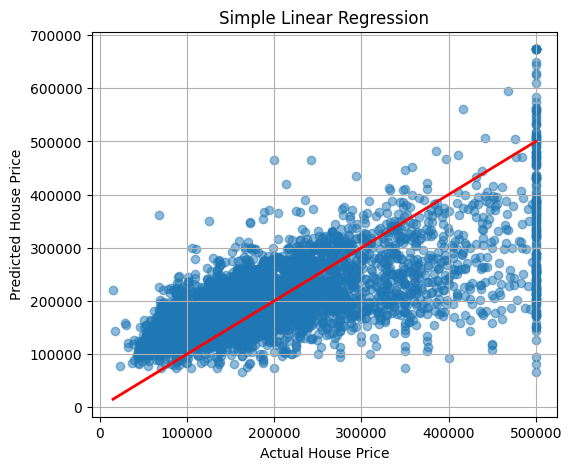

Multiple Linear Regression
MAE  : 50670.49
RMSE : 70059.19
R2   : 0.6254


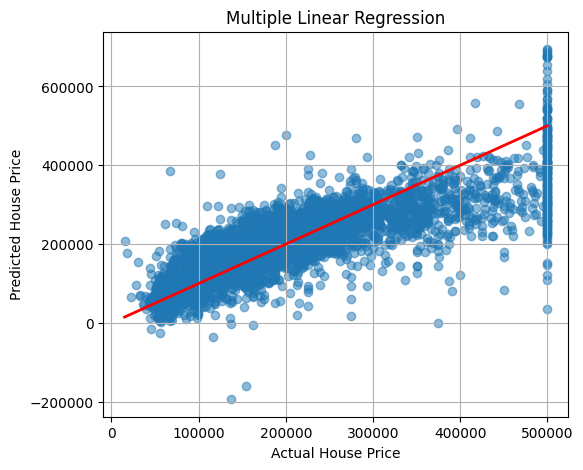

Polynomial Regression
MAE  : 58853.91
RMSE : 79152.15
R2   : 0.5219


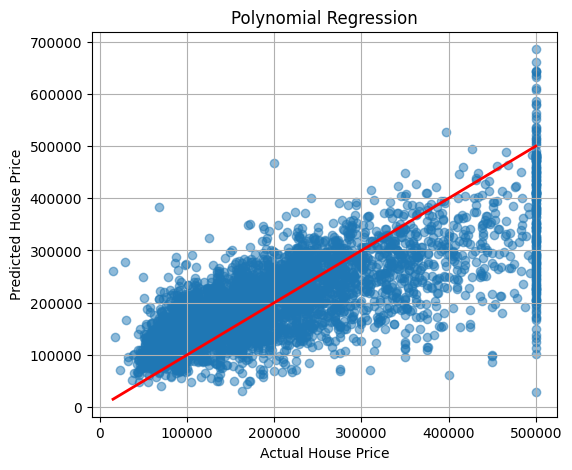

Ridge Regression
MAE  : 50676.92
RMSE : 70066.02
R2   : 0.6254


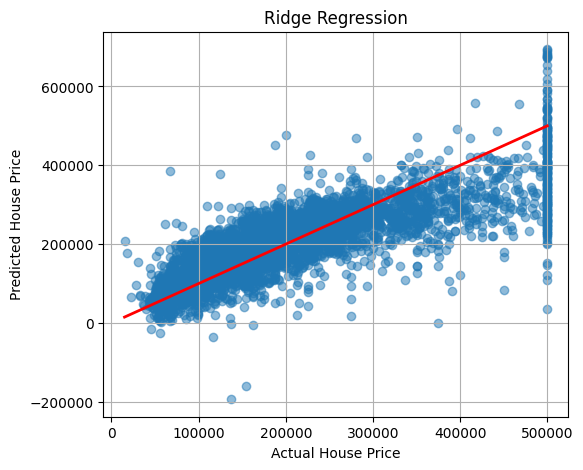

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Split Features and Target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Simple Linear Regression
simple_model = LinearRegression()
simple_model.fit(X_train[["median_income"]], y_train)
simple_pred = simple_model.predict(X_test[["median_income"]])

# Multiple Linear Regression
multiple_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

multiple_model.fit(X_train, y_train)
multiple_pred = multiple_model.predict(X_test)

# Polynomial Regression
poly_features = ["median_income","housing_median_age","total_rooms"]

poly_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train[poly_features], y_train)
poly_pred = poly_model.predict(X_test[poly_features])

# Ridge Regression
ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Store Models
results = {
    "Simple Linear Regression": simple_pred,
    "Multiple Linear Regression": multiple_pred,
    "Polynomial Regression": poly_pred,
    "Ridge Regression": ridge_pred
}

# Evaluation + Graphs
for name, pred in results.items():

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("="*60)
    print(name)
    print("="*60)
    print("MAE  :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R2   :", round(r2,4))

    plt.figure(figsize=(6,5))
    plt.scatter(y_test, pred, alpha=0.5)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linewidth=2
    )
    plt.title(name)
    plt.xlabel("Actual House Price")
    plt.ylabel("Predicted House Price")
    plt.grid(True)
    plt.show()